# Feature Extraction: All Datasets

For each of the five benchmarks this notebook:
1. Loads the response-level JSONL
2. Embeds all responses with `all-MiniLM-L6-v2` (L2-normalised)
4. Extracts the **6 geometric features** per question
5. Saves the feature DataFrame to `../data/temp/processed_csv/`

A combined section concatenates all five DataFrames into a single 2500-question dataset.

---

## Feature Definitions and Formulas

All features are computed from the $N=20$ response embeddings
$\{\mathbf{e}_{j}\}_{j=1}^{N}$ for a single question, where each
$\mathbf{e}_j \in \mathbb{R}^{384}$ is produced by **all-MiniLM-L6-v2**
(L2-normalised, so $\|\mathbf{e}_j\|=1$).

### 1. Semantic Entropy $H_{\text{sem}}$
$$H_{\text{sem}} = -\sum_{k=1}^{K} p_k \log_2 p_k, \qquad p_k = \frac{|C_k|}{N}$$

Responses are grouped into $K$ semantic clusters by agglomerative clustering

=> $H_{\text{sem}} = 0$ means all responses say the same thing (confident);

=> $H_{\text{sem}} \approx \log_2 K$ means responses are uniformly scattered across $K$ distinct meanings (uncertain / hallucinating).

*Reference: Farquhar et al. (2024)*

### 2. Mean Centroid Cosine Distance $D_{\cos}$
$$D_{\cos} = \frac{1}{N}\sum_{j=1}^{N}\left(1 - \cos\!\left(\mathbf{e}_j,\,\frac{\bar{\mathbf{e}}}{\|\bar{\mathbf{e}}\|}\right)\right), \qquad \bar{\mathbf{e}} = \frac{1}{N}\sum_j \mathbf{e}_j$$

=> Mean angular distance from each response to the centroid of the response cloud.

=> High $D_{\cos}$ responses are spread far from their average, which indicate a higher incoherence.

*Reference: Ricco et al. (2025)*

### 3. Variance of Centroid Distance $D_{\cos,\text{var}}$
$$D_{\cos,\text{var}} = \operatorname{Var}_j\!\left[1 - \cos\!\left(\mathbf{e}_j,\,\frac{\bar{\mathbf{e}}}{\|\bar{\mathbf{e}}\|}\right)\right]$$

=> Variance of per-response centroid distances. 

=> Captures **asymmetry**: a small number of very divergent responses inflate this term without necessarily raising the mean.

### 4. Mean Pairwise Cosine Distance $D_{\text{pair}}$
$$D_{\text{pair}} = \frac{1}{\binom{N}{2}}\sum_{j<k}\left(1 - S_{jk}\right), \qquad S_{jk} = \cos(\mathbf{e}_j, \mathbf{e}_k)$$

=> Mean cosine distance across **all response pairs**: not relative to a centroid.
=> Complementary to $D_{\cos}$: captures spread between responses directly.

### 5. Cluster Count $K$
$$K = \text{number of agglomerative clusters}$$

=> Directly counts the number of distinct semantic meanings in the response set.

### 6. Pairwise Similarity Variance $\sigma^2_S$
$$\sigma^2_S = \operatorname{Var}\{S_{jk} : j < k\}, \qquad S_{jk} = \cos(\mathbf{e}_j, \mathbf{e}_k)$$

=> Variance of all $\binom{N}{2}$ pairwise cosine similarities.

=> Low variance implies that all responses agree uniformly; high variance implies a mixed-cluster structure.

---

### Vectorised Cosine Computation

Because the embeddings are L2-normalised, the full $N \times N$ cosine
similarity matrix reduces to a dot-product:
$$\mathbf{S} = \mathbf{E}\,\mathbf{E}^\top, \qquad \mathbf{E}\in\mathbb{R}^{N\times d}$$
Stacking all questions into a tensor $\mathcal{E}\in\mathbb{R}^{M\times N\times d}$
allows computing all $M$ similarity matrices in a single batched matmul.
$D_{\text{pair}}$, $D_{\cos}$, $D_{\cos,\text{var}}$, and $\sigma^2_S$ are all
derived from this matrix in one vectorised pass.

## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from spectral_detection.data.cleaning import (
    load_dataset, add_canonical_domain, questions_per_domain, FEATURES, FEATURE_LABELS,
)
from spectral_detection.analysis.eda import print_loading_summary, print_filtering_diagnostic
from spectral_detection.feature_extraction import (
    extract_question_features, build_domain_stats,
)
from spectral_detection.visualization import (
    plot_feature_distributions, plot_correlation_matrix,
    plot_entropy_vs_dispersion, plot_hallucination_rate_by_domain,
)

from spectral_detection.feature_extraction import (
    embed_responses, extract_question_features, build_domain_stats,
)

## Configuration

In [2]:
DATA_DIR   = '../data/processed'
CSV_DIR    = '../data/temp/processed_csv/'
NPY_DIR    = '../data/temp/pny/'
OUTPUT_DIR = '../data/processed/temp/'
for d in [CSV_DIR, NPY_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

SIM_THRESHOLD = 0.85
MIN_QUESTIONS  = 10
SEED = 42
np.random.seed(SEED)

DATASET_FILES = {
    'defan':      ('defan_t0.9_n20.jsonl',   'domain'),
    'halueval':   ('halueval_t1.0_n20.jsonl', 'domain_canonical'),
    'mmlu':       ('mmlu_t1.0_n20.jsonl',     'domain_canonical'),
    'triviaqa':   ('triviaqa_t1.0_n20.jsonl', 'domain_canonical'),
    'truthfulqa': ('truthfulqa_t1.0_n20.jsonl','domain_canonical'),
}

---
## Per-Dataset Feature Extraction

Each dataset: load, embed, extract 6 features, visualise, save.

> **Domain caveat (applies to all datasets below):** Domain labels are LLM-assigned and noisy.
> Hallucination rate by domain plots are exploratory only. We do not train or test on domain splits.


  DEFAN
Dataset:          defan
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2377  (23.8%)
  incorrect   :   7621  (76.2%)
  refused     :      2  (0.0%)

Domains (7 unique):
  Humanities
  Law, Business, and Miscellaneous
  Medicine & Health
  STEM
  Science & Technology
  Social Sciences
  Sports

Answer types: ['city', 'date', 'name', 'numeric']
Loading cached embeddings from ../data/temp/pny/defan_embeddings.npy
Vectorised path: 500 questions x 20 responses
  500/500 ...

Processed: 500  |  Skipped (all-refused): 0
Label: Correct=102, Hallucinated=398, Rate=79.6%


,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S,label
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,2.6244,0.2502,0.0194,0.4424,10.1760,0.0484,0.7960
std,1.2506,0.1326,0.0160,0.2113,5.5457,0.0290,0.4034
min,-0.0000,0.0031,0.0000,0.0064,1.0000,0.0001,0.0000
25%,1.5788,0.1340,0.0087,0.2631,5.0000,0.0288,1.0000
50%,2.9219,0.2622,0.0158,0.4797,11.0000,0.0441,1.0000
75%,3.7219,0.3624,0.0252,0.6247,15.0000,0.0611,1.0000
max,4.3219,0.5132,0.1149,0.8032,20.0000,0.1790,1.0000


No questions were skipped.

Surviving questions per domain:
  Humanities                              :  193 /  203  (dropped 10)
  STEM                                    :  137 /  140  (dropped 3)
  Social Sciences                         :  126 /  166  (dropped 40)
  Sports                                  :   28 /   49  (dropped 21)
  Medicine & Health                       :   16 /   16  (dropped 0)

Domains for ML (>= 10 questions): 5


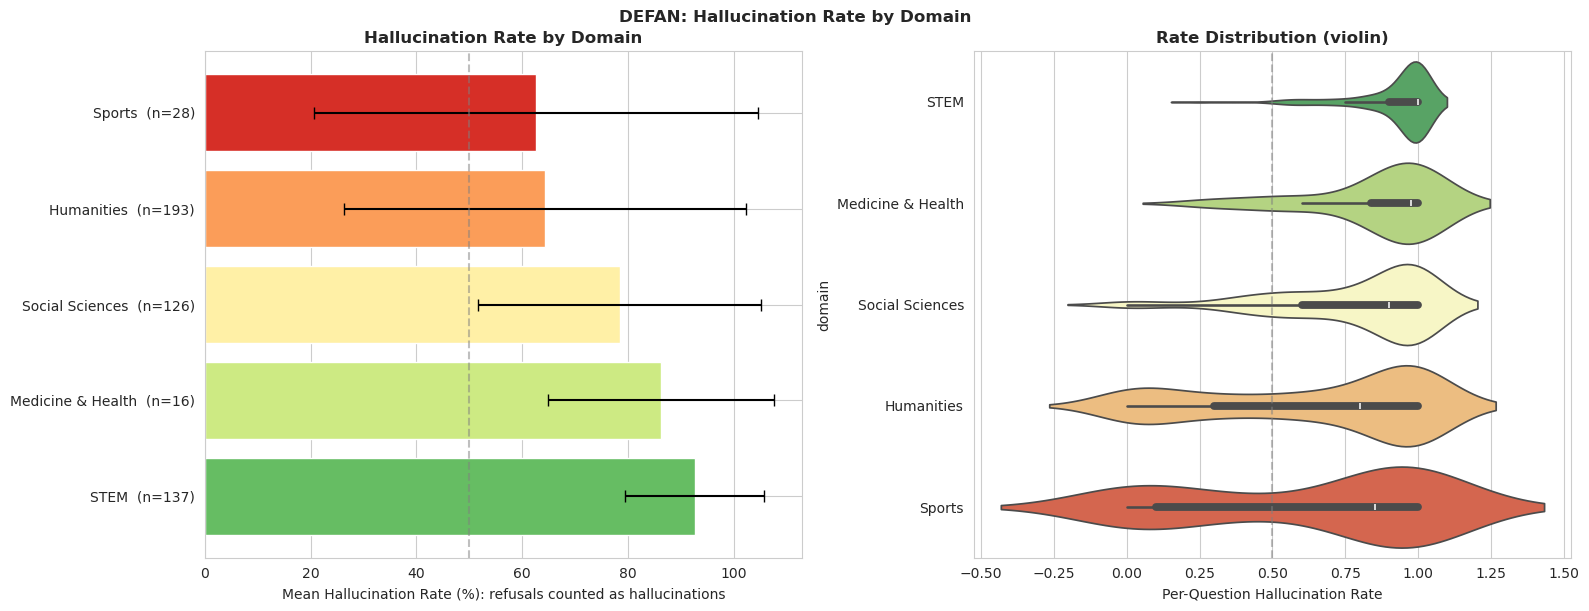

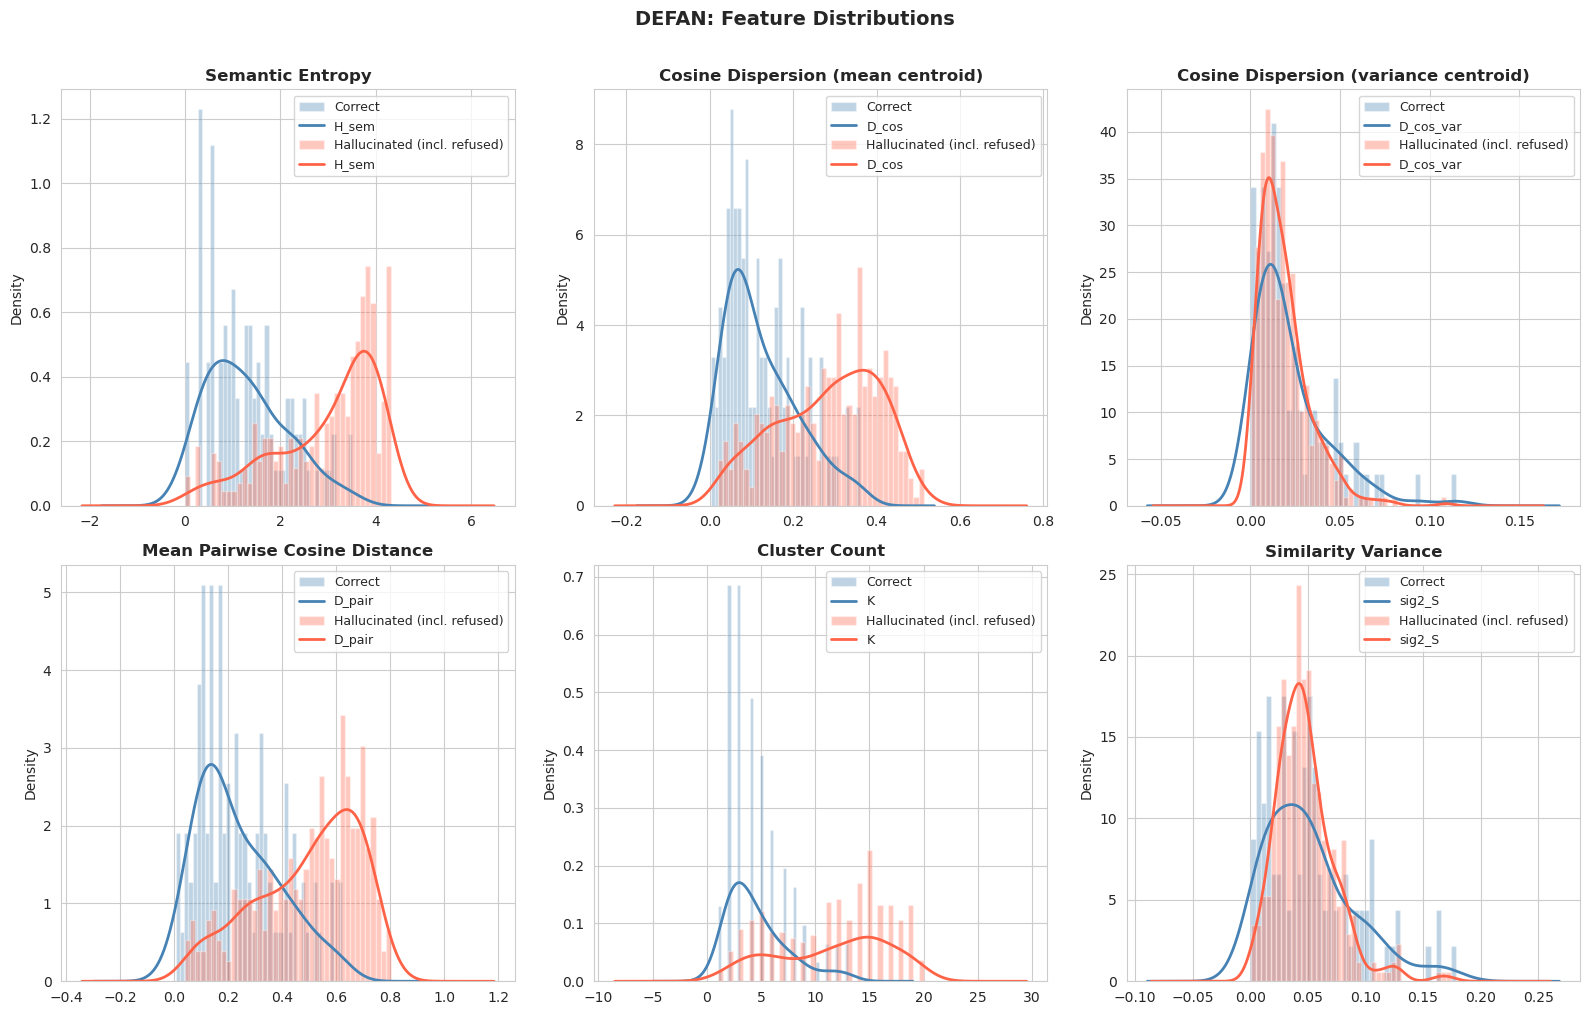

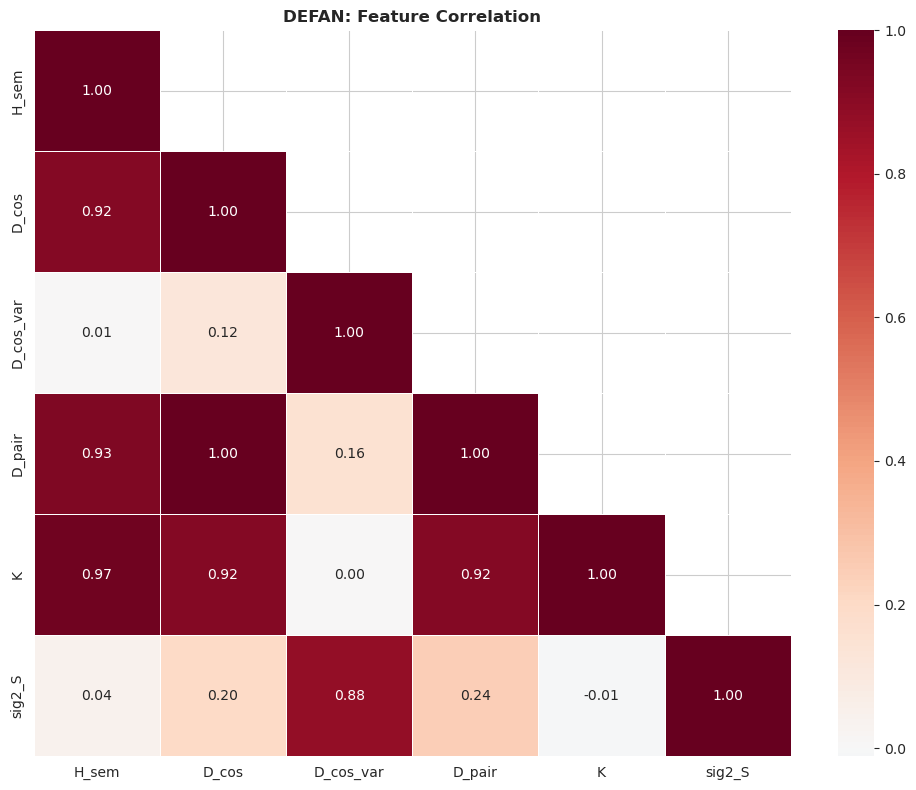

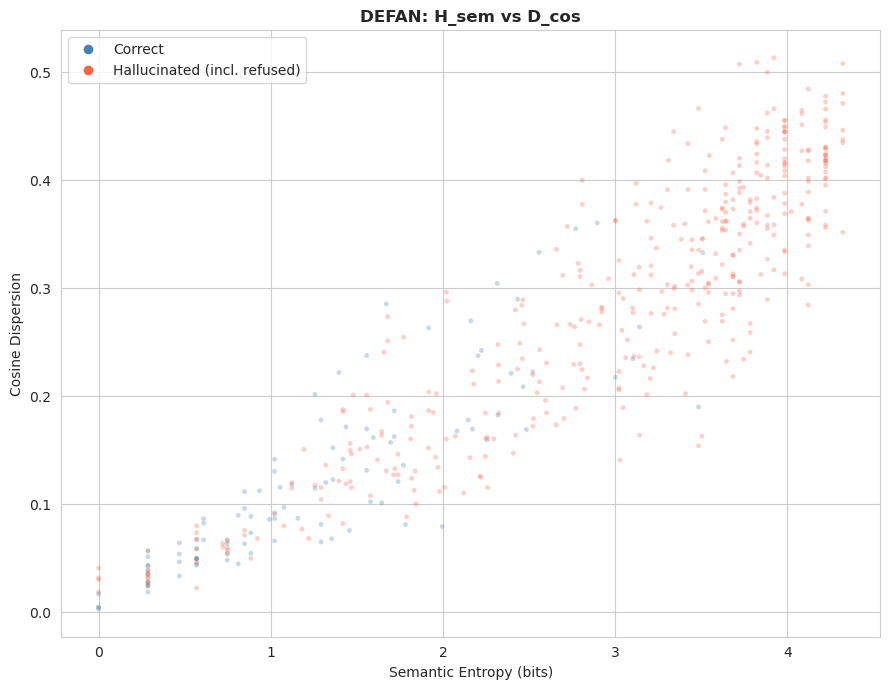

Saved defan: (500, 29)

  HALUEVAL
Dataset:          halueval
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   8984  (89.8%)
  incorrect   :   1006  (10.1%)
  refused     :     10  (0.1%)

Domains (30 unique)  (showing 10 of 30):
  Business
  Business, Food & Beverage
  Business, Hospitality, Entertainment
  Business, Industry, and Miscellaneous
  Business, Law, and Miscellaneous
  Business, Miscellaneous
  Business, Non-profit
  Business, Social Sciences
  Business, Technology
  Business, and Miscellaneous
  ...
Loading cached embeddings from ../data/temp/pny/halueval_embeddings.npy
Vectorised path: 500 questions x 20 responses
  500/500 ...

Processed: 500  |  Skipped (all-refused): 0
Label: Correct=464, Hallucinated=36, Rate=7.2%


,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S,label
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,0.7715,0.0722,0.0121,0.1376,3.1400,0.0313,0.0720
std,0.9270,0.0926,0.0179,0.1653,2.9964,0.0410,0.2587
min,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.0000,0.0000
25%,-0.0000,0.0033,0.0000,0.0069,1.0000,0.0002,0.0000
50%,0.4690,0.0357,0.0033,0.0737,2.0000,0.0114,0.0000
75%,1.2231,0.1043,0.0183,0.2081,4.0000,0.0567,0.0000
max,4.3219,0.4722,0.1369,0.7594,20.0000,0.2523,1.0000


No questions were skipped.

Surviving questions per domain:
  Humanities                              :  248 /  276  (dropped 28)
  STEM                                    :  105 /  122  (dropped 17)
  Social Sciences                         :   88 /  115  (dropped 27)
  Law & Business                          :   22 /   27  (dropped 5)
  Entertainment                           :   19 /   37  (dropped 18)
  Sports                                  :   11 /   19  (dropped 8)
  Medicine & Health                       :    7 /    7  (dropped 0)  *** BELOW THRESHOLD

Domains for ML (>= 10 questions): 6
Excluded: ['Medicine & Health']


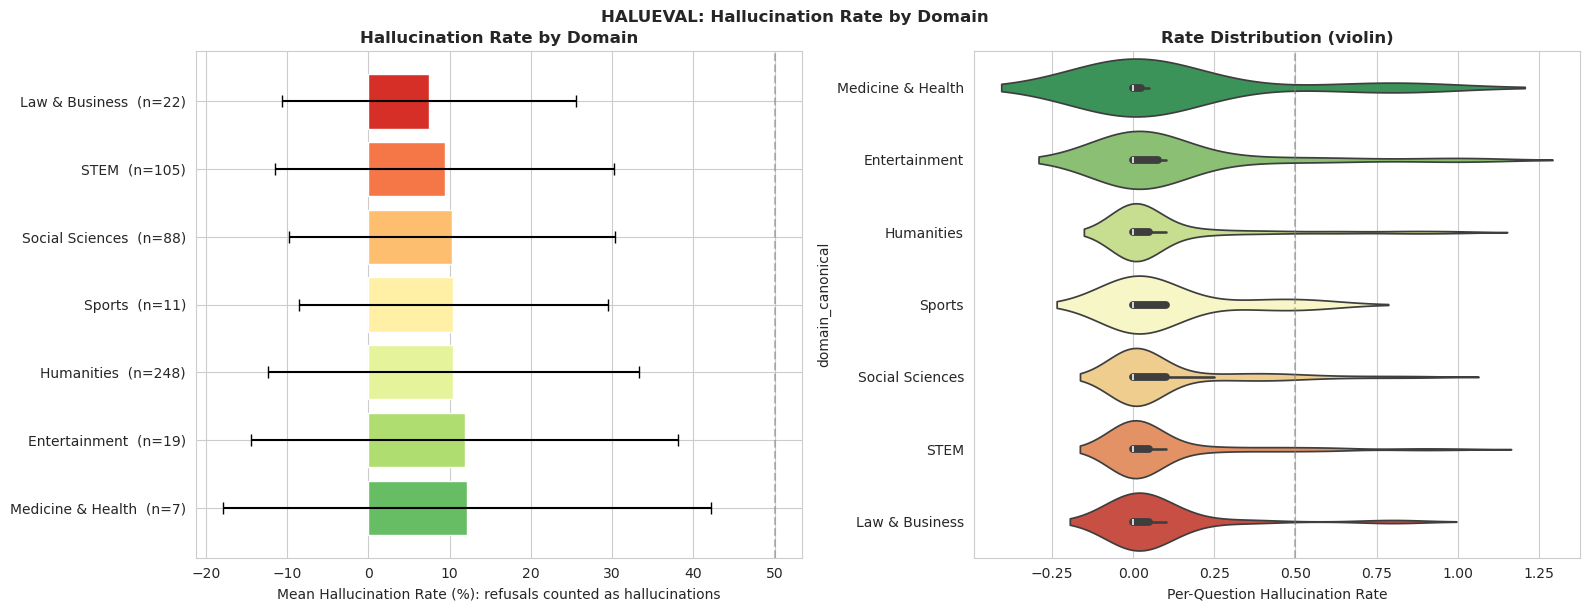

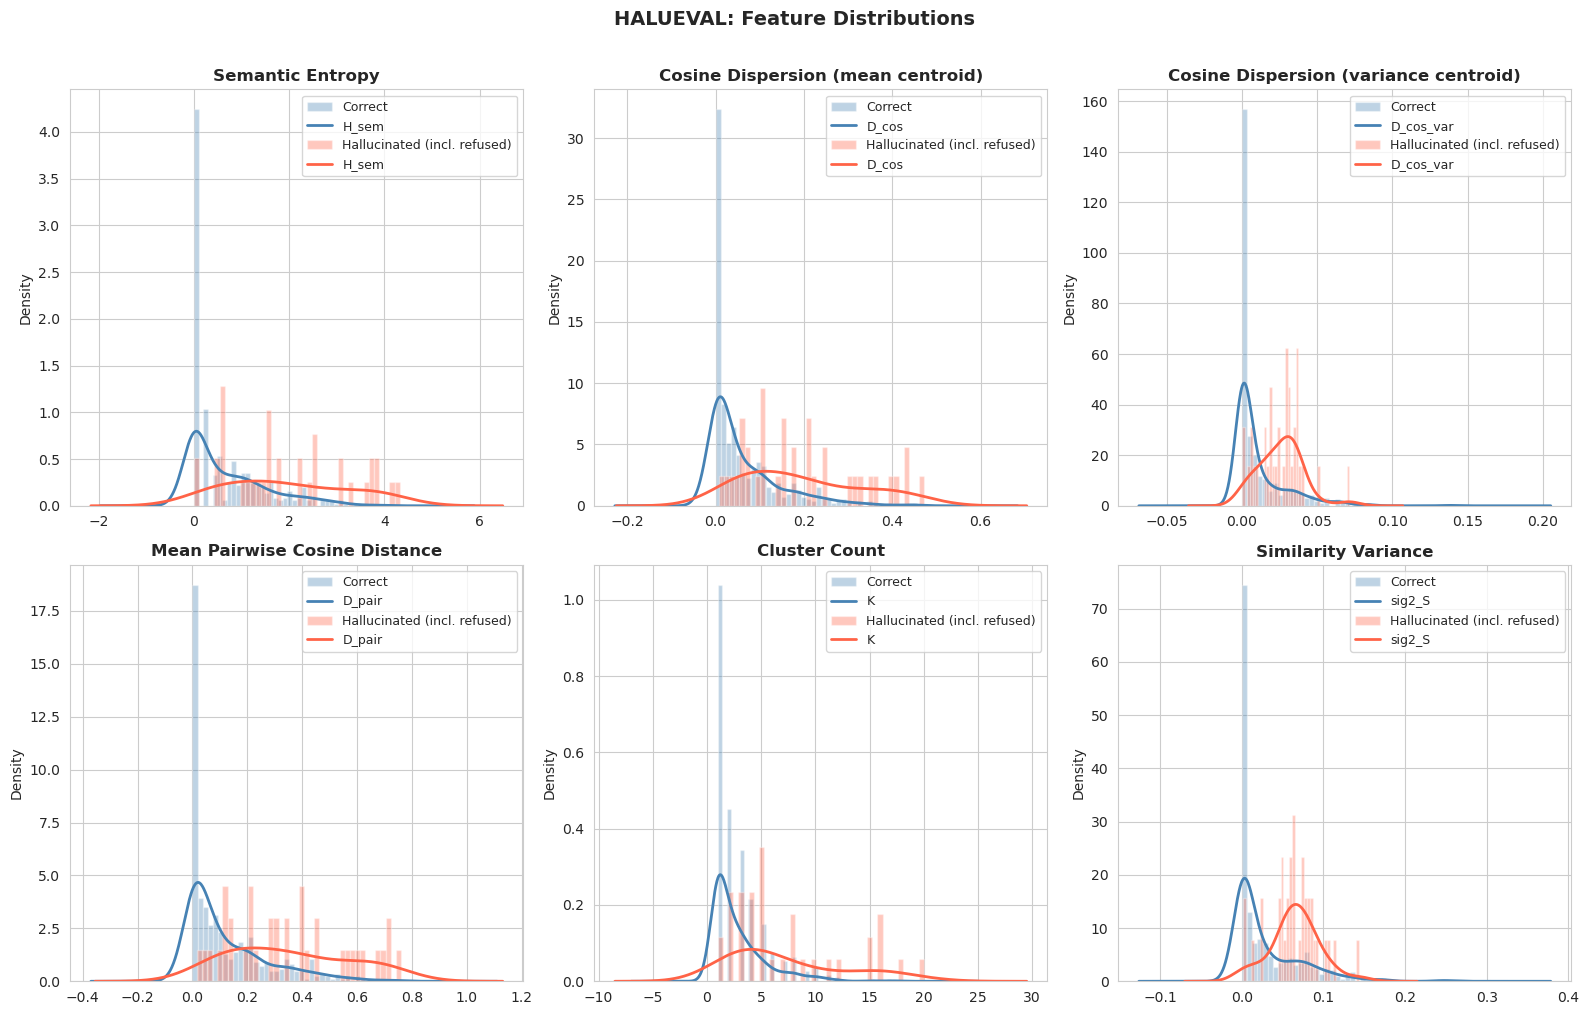

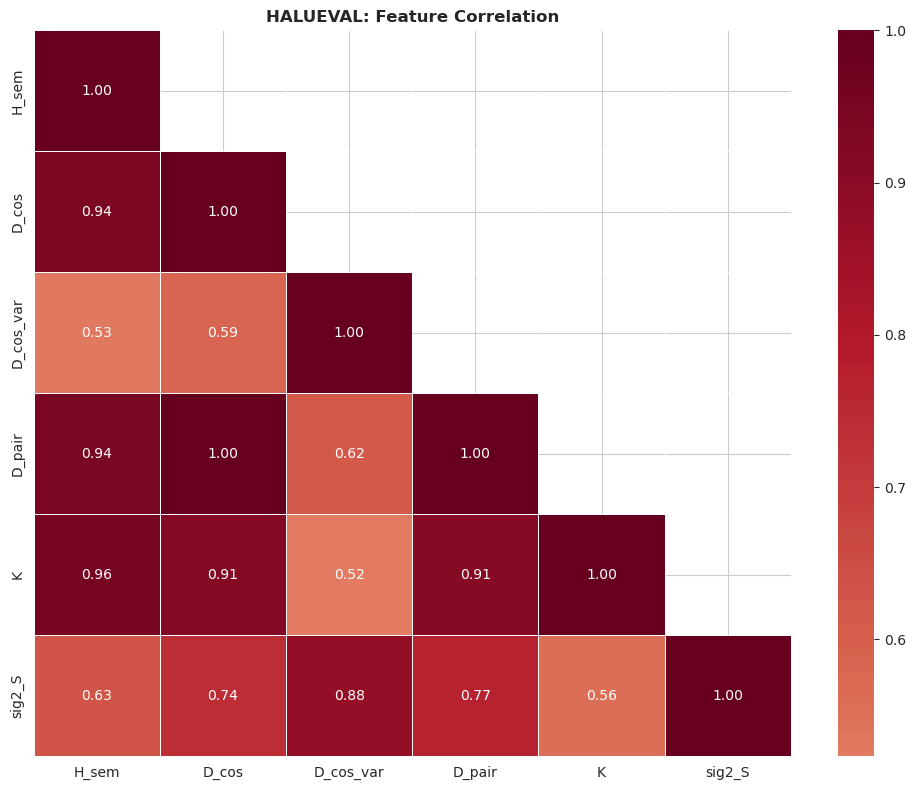

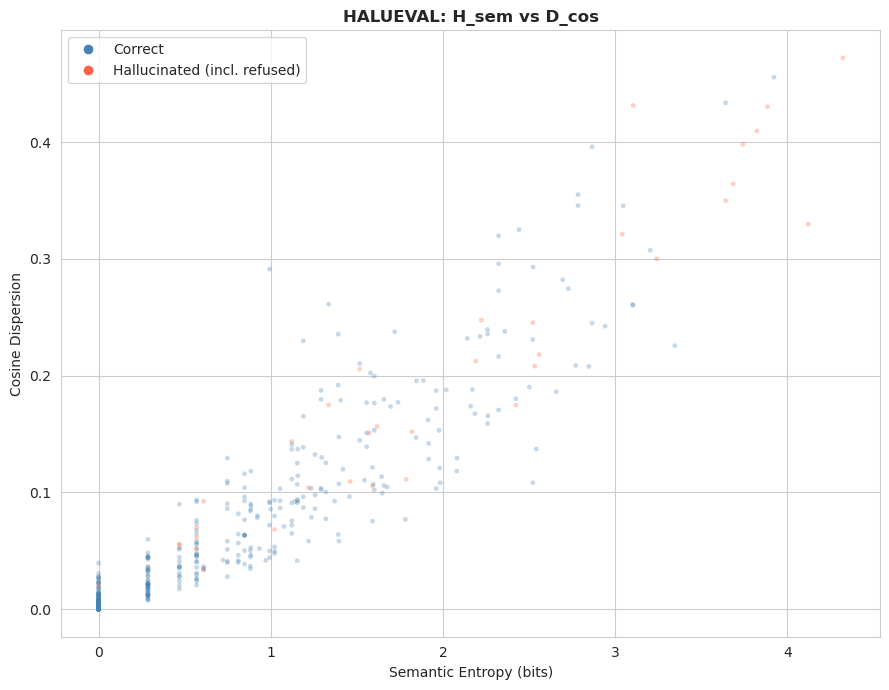

Saved halueval: (500, 28)

  MMLU
Dataset:          mmlu
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2732  (27.3%)
  incorrect   :   7267  (72.7%)
  refused     :      1  (0.0%)

Domains (65 unique)  (showing 10 of 65):
  Biology
  Business
  Business, Economics, and Marketing
  Business, Finance, and Accounting
  Business, Finance, and Economics
  Business, Finance, and Miscellaneous
  Business, Law, and Miscellaneous
  Business, Management, and Miscellaneous
  Business, Marketing
  Business, Marketing, and Economics
  ...
Loading cached embeddings from ../data/temp/pny/mmlu_embeddings.npy
Vectorised path: 500 questions x 20 responses
  500/500 ...

Processed: 500  |  Skipped (all-refused): 0
Label: Correct=108, Hallucinated=392, Rate=78.4%


,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S,label
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,3.8532,0.2129,0.0181,0.3974,16.3660,0.0333,0.7840
std,0.5142,0.0548,0.0135,0.0899,3.2238,0.0205,0.4119
min,0.2864,0.0537,0.0007,0.1101,2.0000,0.0027,0.0000
25%,3.6464,0.1723,0.0064,0.3314,15.0000,0.0161,1.0000
50%,4.0219,0.2088,0.0149,0.3937,17.0000,0.0297,1.0000
75%,4.2219,0.2499,0.0273,0.4604,19.0000,0.0467,1.0000
max,4.3219,0.3878,0.0593,0.6581,20.0000,0.0996,1.0000


No questions were skipped.

Surviving questions per domain:
  STEM                                    :  153 /  196  (dropped 43)
  Social Sciences                         :  145 /  184  (dropped 39)
  Humanities                              :   72 /  116  (dropped 44)
  Law & Business                          :   72 /  108  (dropped 36)
  Medicine & Health                       :   55 /   68  (dropped 13)
  Sports                                  :    1 /    1  (dropped 0)  *** BELOW THRESHOLD
  Entertainment                           :    1 /    5  (dropped 4)  *** BELOW THRESHOLD
  Food & Nutrition                        :    1 /    3  (dropped 2)  *** BELOW THRESHOLD

Domains for ML (>= 10 questions): 5
Excluded: ['Entertainment', 'Food & Nutrition', 'Sports']


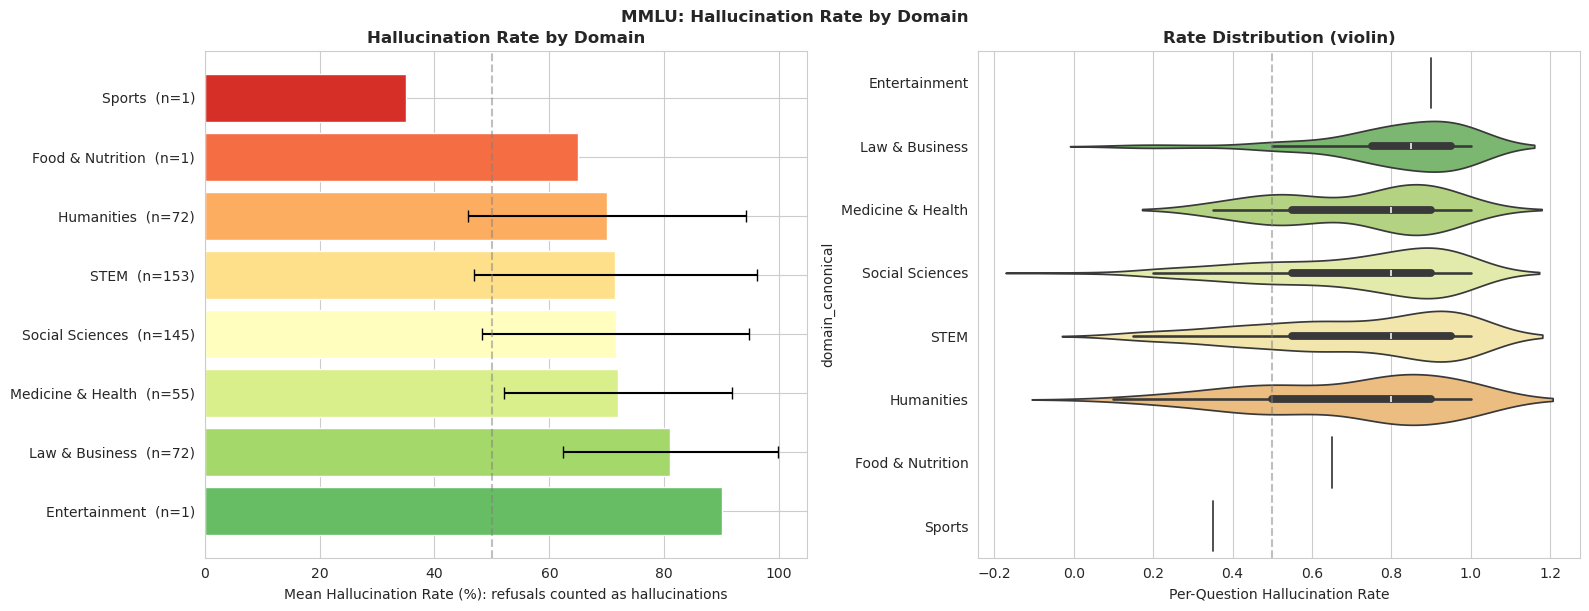

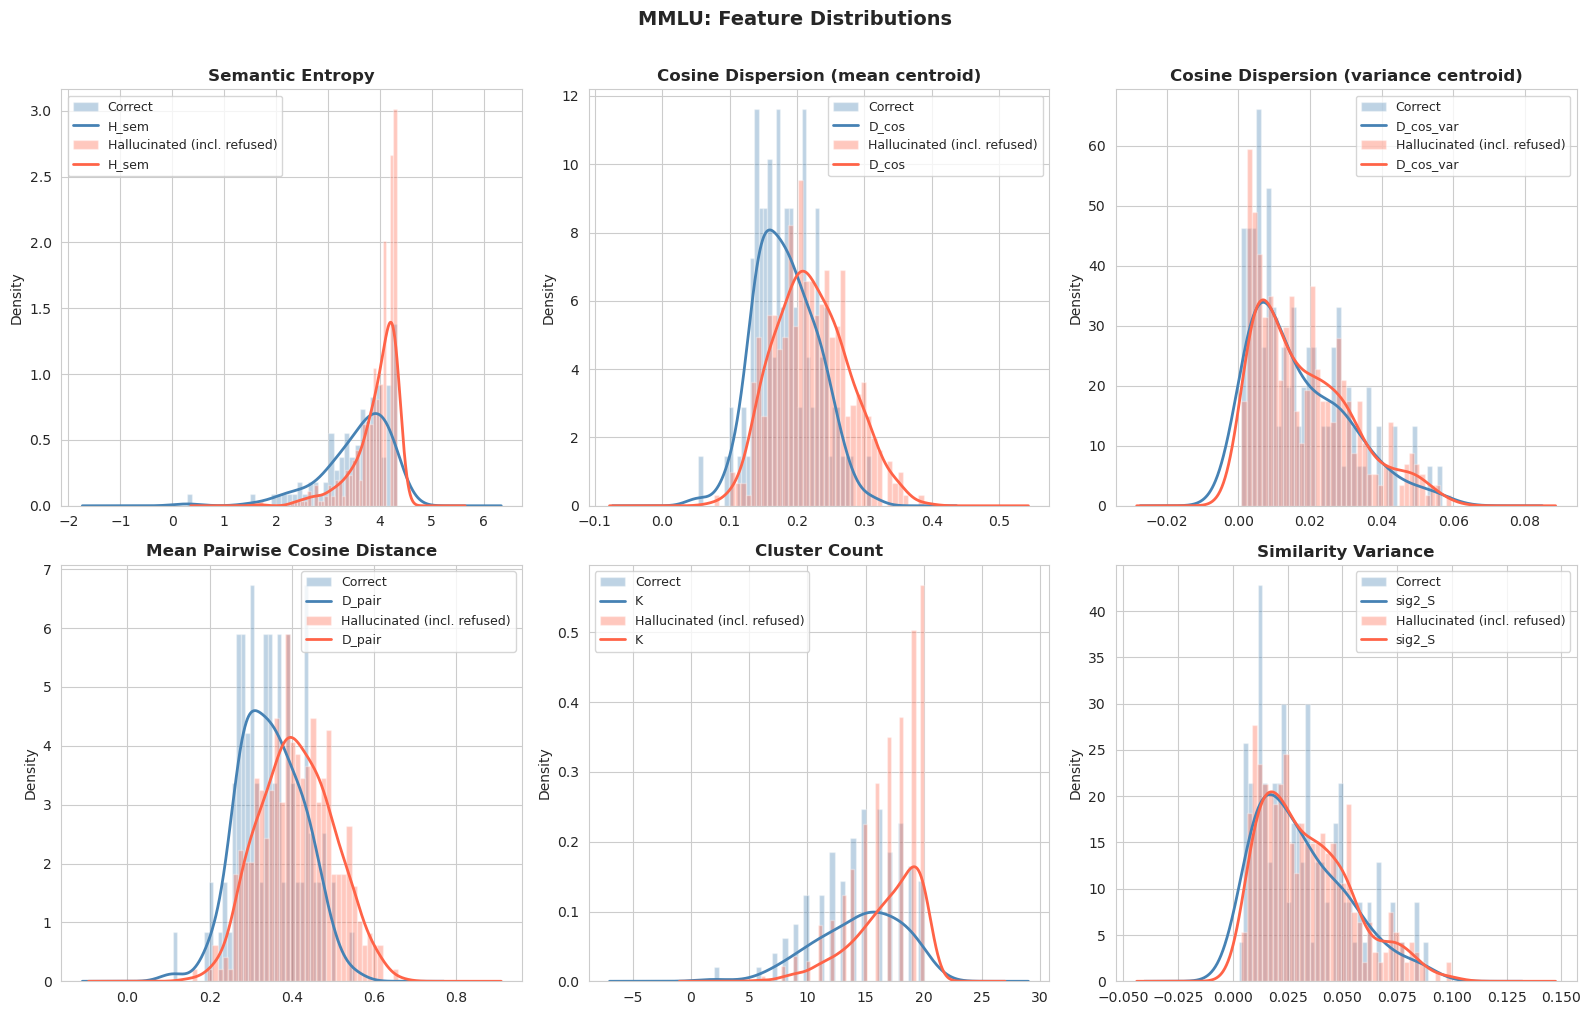

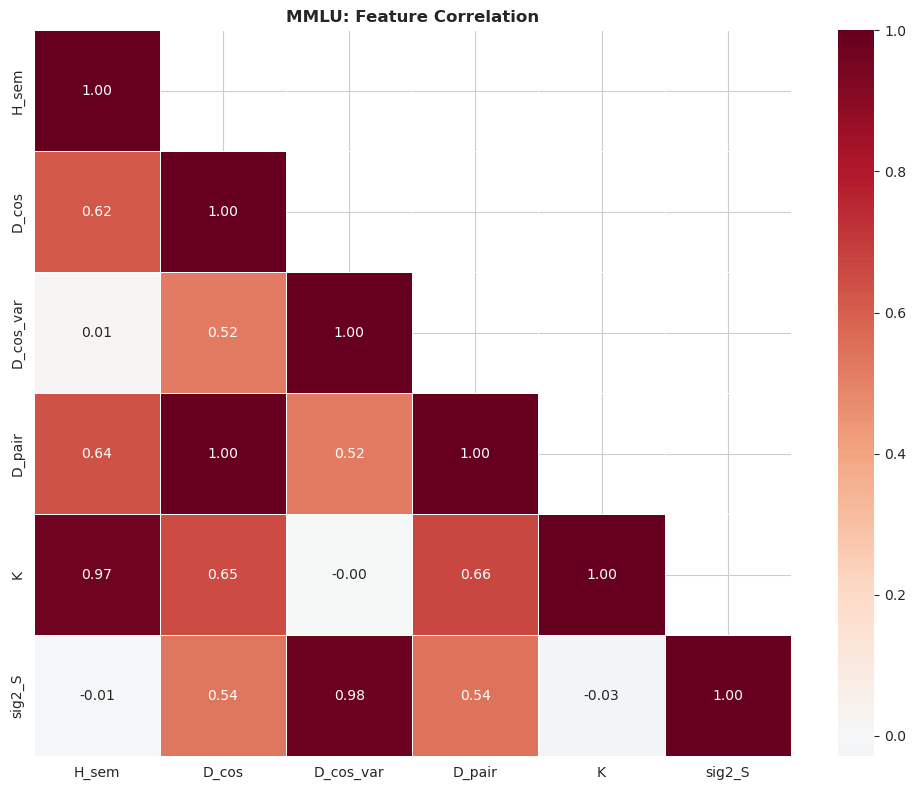

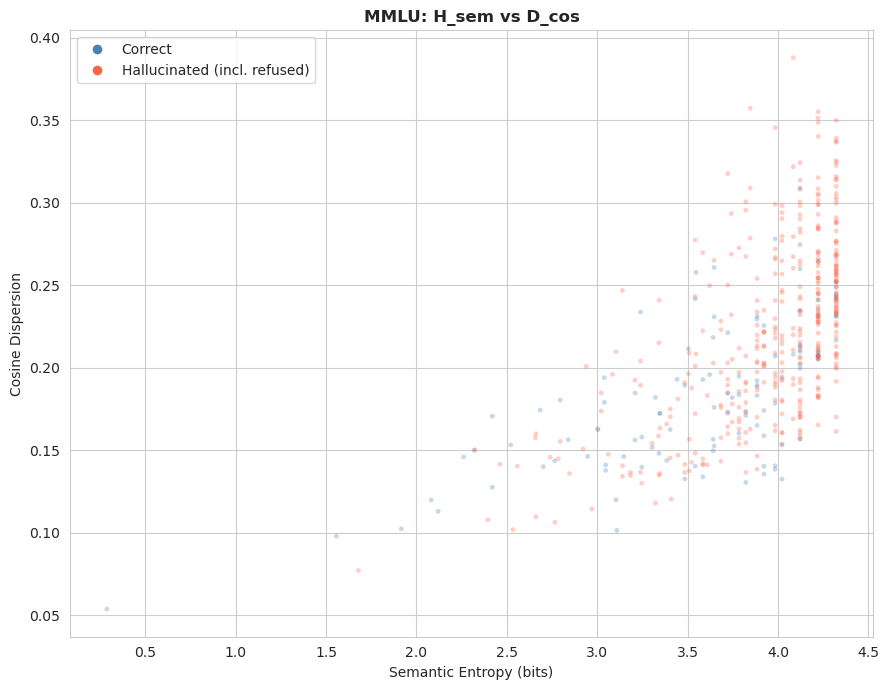

Saved mmlu: (500, 28)

  TRIVIAQA
Dataset:          triviaqa
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   5706  (57.1%)
  incorrect   :   4293  (42.9%)
  refused     :      1  (0.0%)

Domains (64 unique)  (showing 10 of 64):
  Automotive
  Automotive & Logos
  Automotive/Brand Logo
  Automotive/Branding
  Biology
  Design & Branding
  Entertainment
  Entertainment & Fiction
  Entertainment & Media
  Fashion
  ...
Loading cached embeddings from ../data/temp/pny/triviaqa_embeddings.npy
Vectorised path: 500 questions x 20 responses
  500/500 ...

Processed: 500  |  Skipped (all-refused): 0
Label: Correct=292, Hallucinated=208, Rate=41.6%


,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S,label
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,1.4917,0.1564,0.0165,0.2801,5.7840,0.0438,0.4160
std,1.3724,0.1492,0.0181,0.2516,5.2502,0.0413,0.4934
min,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.0000,0.0000
25%,-0.0000,0.0109,0.0006,0.0228,1.0000,0.0023,0.0000
50%,1.1901,0.1182,0.0109,0.2341,4.0000,0.0343,0.0000
75%,2.6464,0.2818,0.0255,0.5097,9.0000,0.0704,1.0000
max,4.3219,0.5493,0.0972,0.8389,20.0000,0.1679,1.0000


No questions were skipped.

Surviving questions per domain:
  Humanities                              :  201 /  248  (dropped 47)
  STEM                                    :  129 /  159  (dropped 30)
  Social Sciences                         :   84 /  125  (dropped 41)
  Sports                                  :   17 /   30  (dropped 13)
  Medicine & Health                       :   13 /   15  (dropped 2)
  Entertainment                           :   12 /   25  (dropped 13)
  Law & Business                          :    9 /   13  (dropped 4)  *** BELOW THRESHOLD
  History                                 :    8 /   15  (dropped 7)  *** BELOW THRESHOLD
  Literature                              :    8 /   14  (dropped 6)  *** BELOW THRESHOLD
  Geography                               :    8 /   13  (dropped 5)  *** BELOW THRESHOLD
  Other                                   :    5 /   14  (dropped 9)  *** BELOW THRESHOLD
  Language                                :    3 /    4  (dropped 1)  *

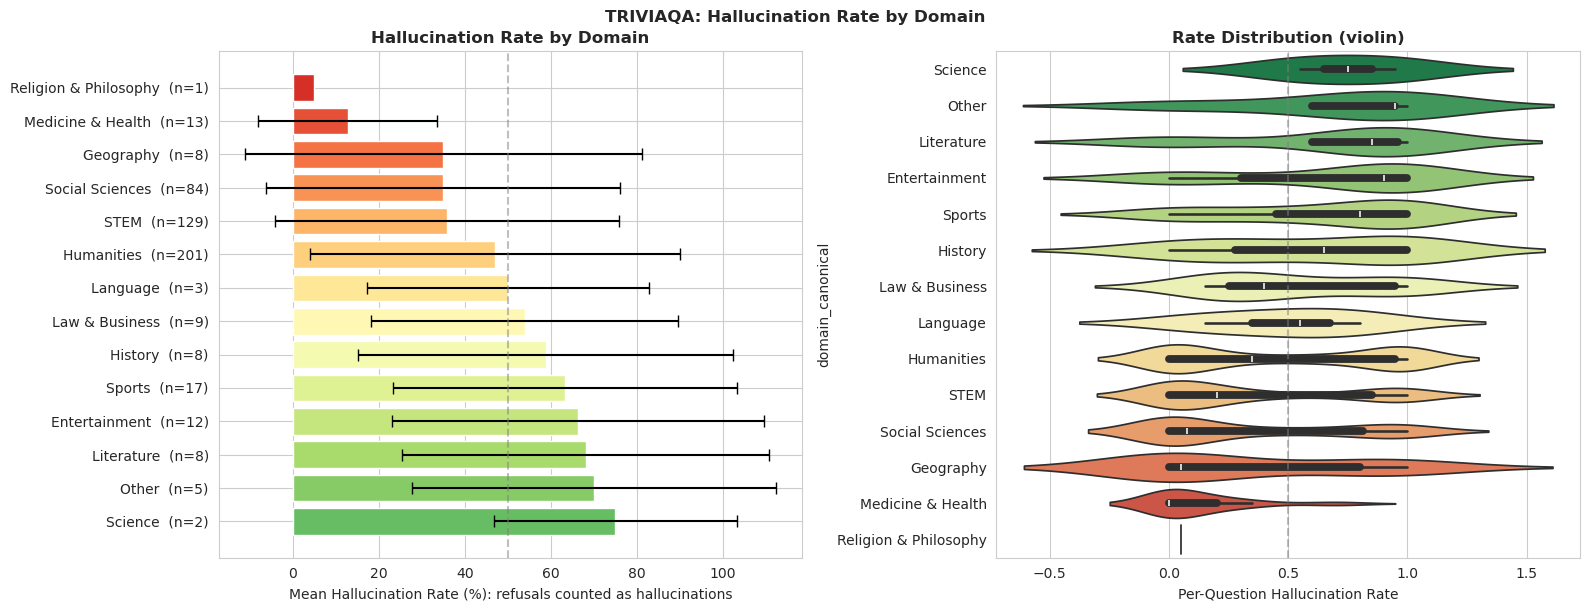

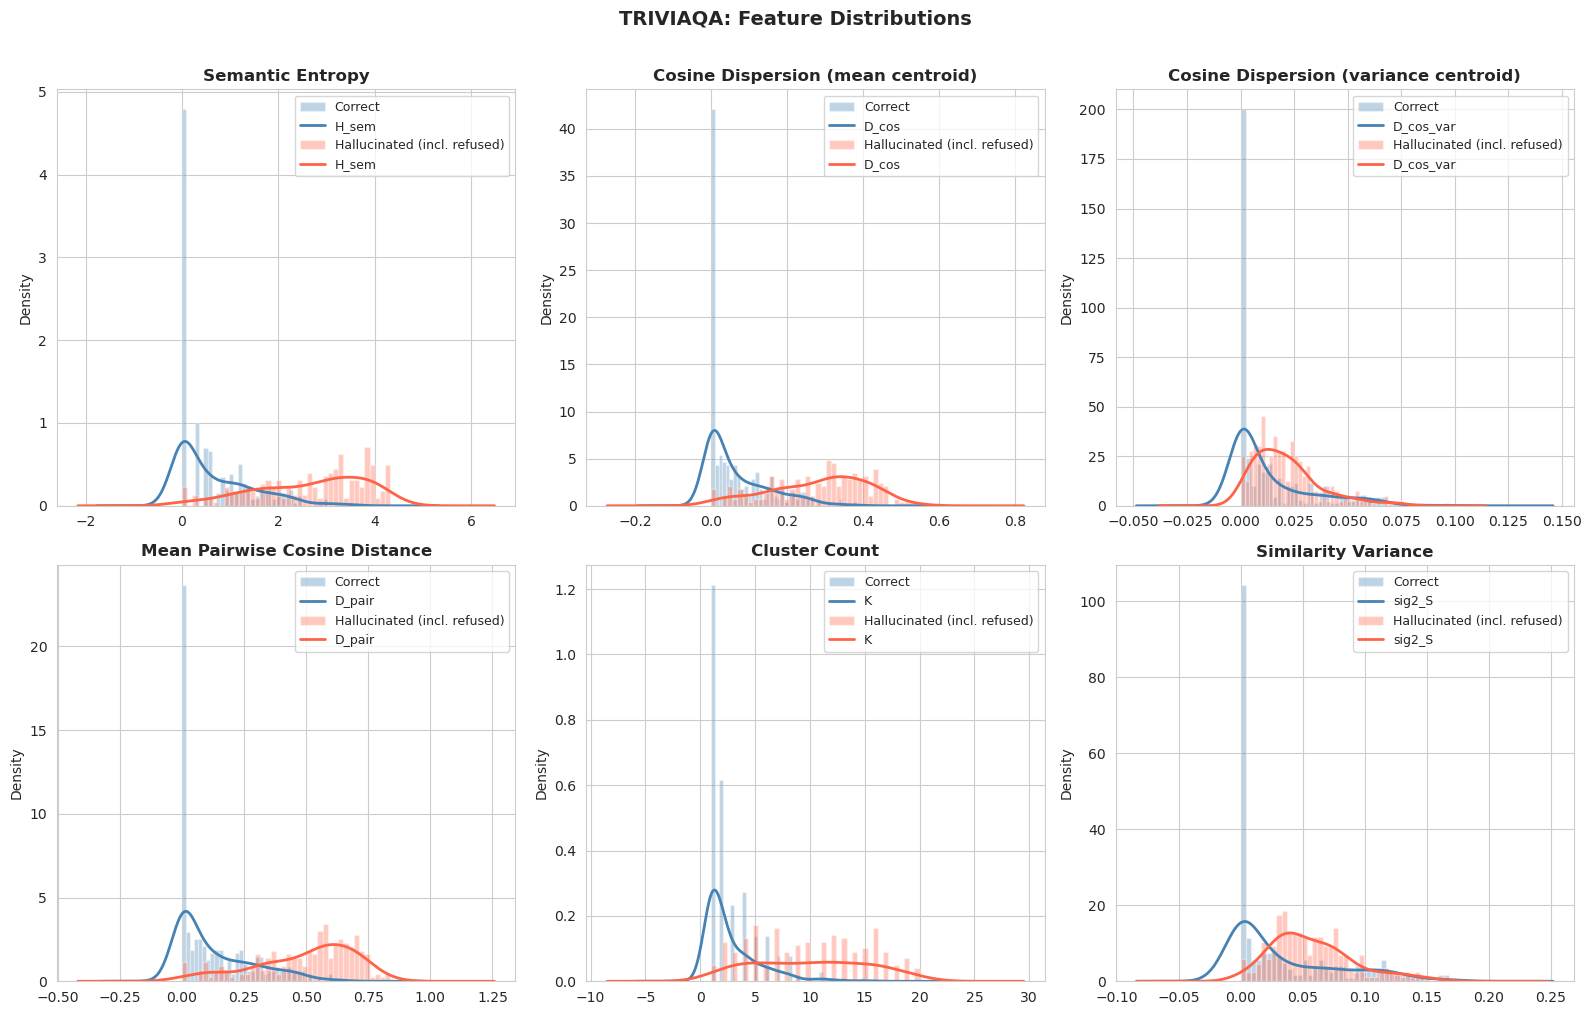

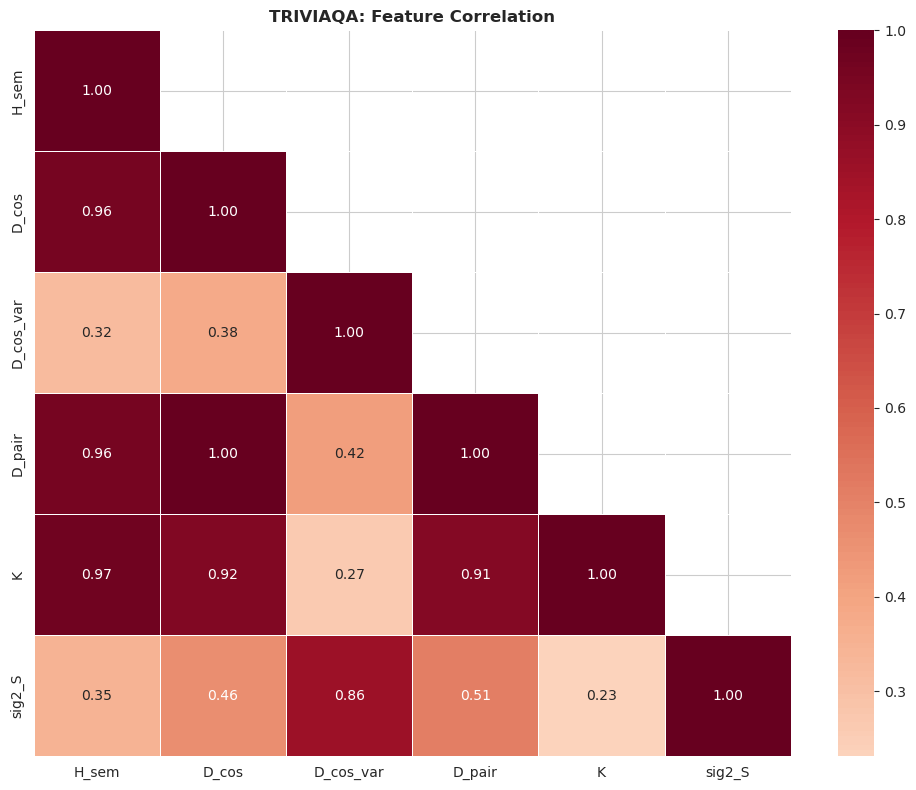

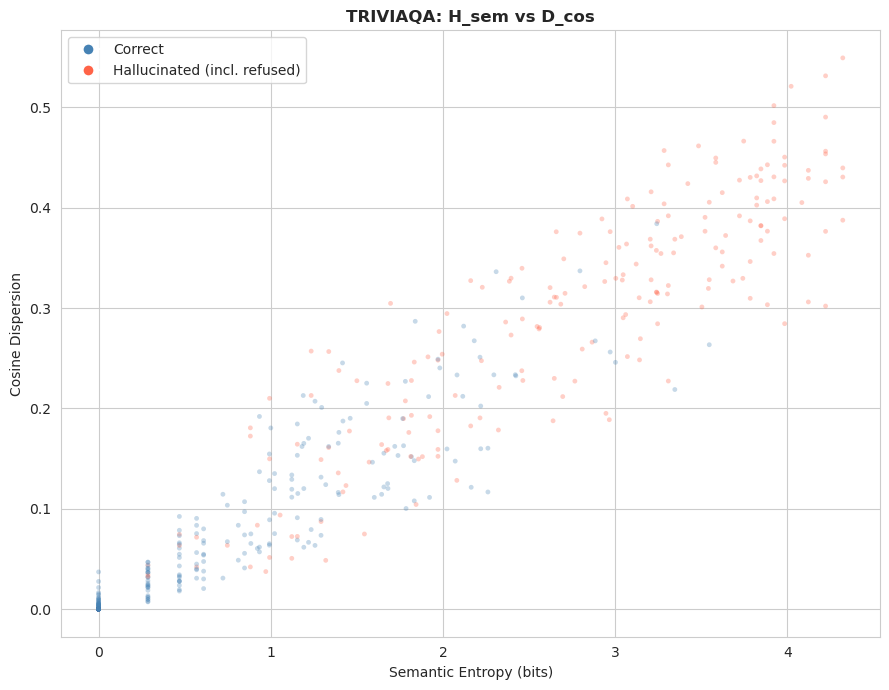

Saved triviaqa: (500, 28)

  TRUTHFULQA
Dataset:          truthfulqa
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2827  (28.3%)
  incorrect   :   7025  (70.2%)
  refused     :    148  (1.5%)

Domains (90 unique)  (showing 10 of 90):
  Agriculture
  Agriculture & Animal Welfare
  Animal Behavior
  Animal Behavior and Learning
  Animal Welfare
  Animal Welfare & Agriculture
  Animals & Wildlife
  Art & History
  Arts
  Arts and Culture
  ...
Loading cached embeddings from ../data/temp/pny/truthfulqa_embeddings.npy
Vectorised path: 500 questions x 20 responses
  500/500 ...

Processed: 500  |  Skipped (all-refused): 0
Label: Correct=140, Hallucinated=360, Rate=72.0%


,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S,label
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,2.5112,0.2450,0.0208,0.4278,10.0920,0.0494,0.7200
std,1.4078,0.1538,0.0169,0.2461,6.1095,0.0334,0.4494
min,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.0000,0.0000
25%,1.1918,0.1077,0.0083,0.2146,4.0000,0.0259,0.0000
50%,2.7955,0.2548,0.0167,0.4682,10.0000,0.0414,1.0000
75%,3.7936,0.3761,0.0294,0.6428,16.0000,0.0680,1.0000
max,4.3219,0.5781,0.1024,0.8653,20.0000,0.1585,1.0000


No questions were skipped.

Surviving questions per domain:
  Social Sciences                         :  169 /  218  (dropped 49)
  Humanities                              :  126 /  180  (dropped 54)
  STEM                                    :  101 /  136  (dropped 35)
  Medicine & Health                       :   50 /   61  (dropped 11)
  Law & Business                          :   35 /   45  (dropped 10)
  History                                 :    5 /   11  (dropped 6)  *** BELOW THRESHOLD
  Science                                 :    3 /   18  (dropped 15)  *** BELOW THRESHOLD
  Other                                   :    2 /   18  (dropped 16)  *** BELOW THRESHOLD
  Food & Nutrition                        :    2 /    3  (dropped 1)  *** BELOW THRESHOLD
  Mathematics                             :    2 /    3  (dropped 1)  *** BELOW THRESHOLD
  Language                                :    1 /    4  (dropped 3)  *** BELOW THRESHOLD
  Entertainment                           :    1

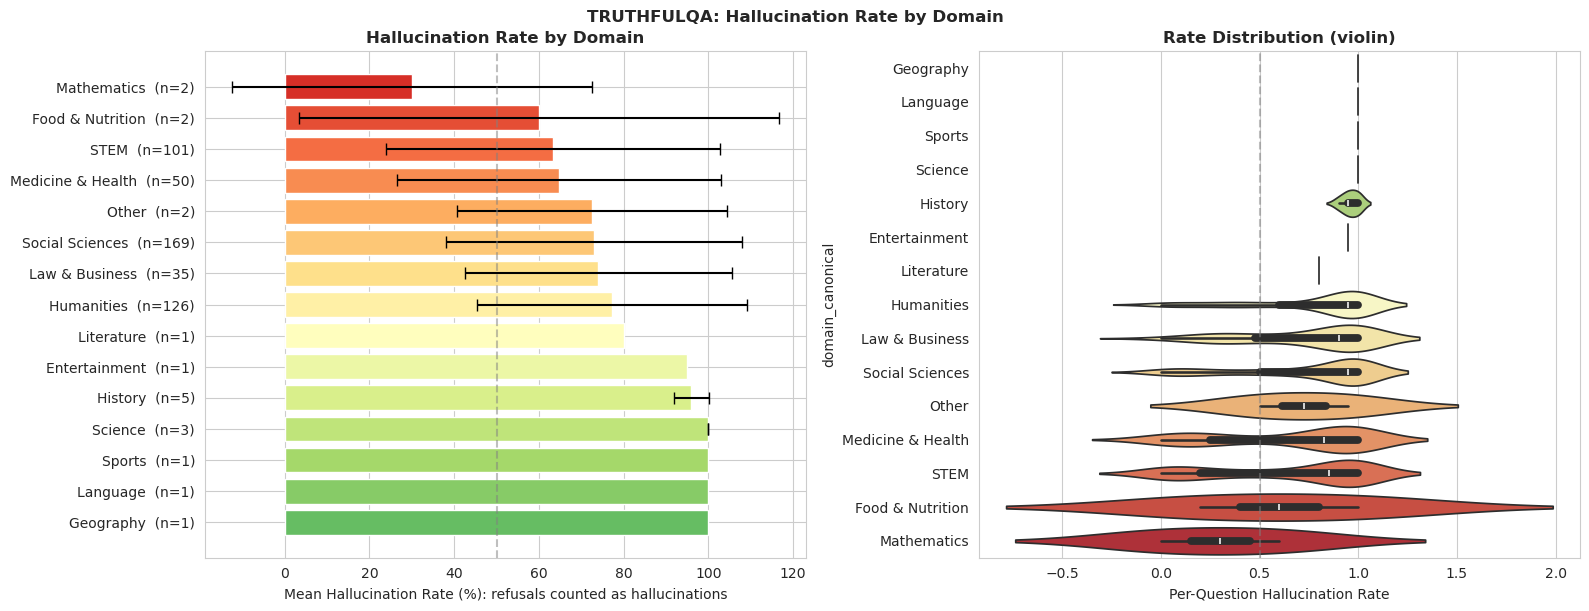

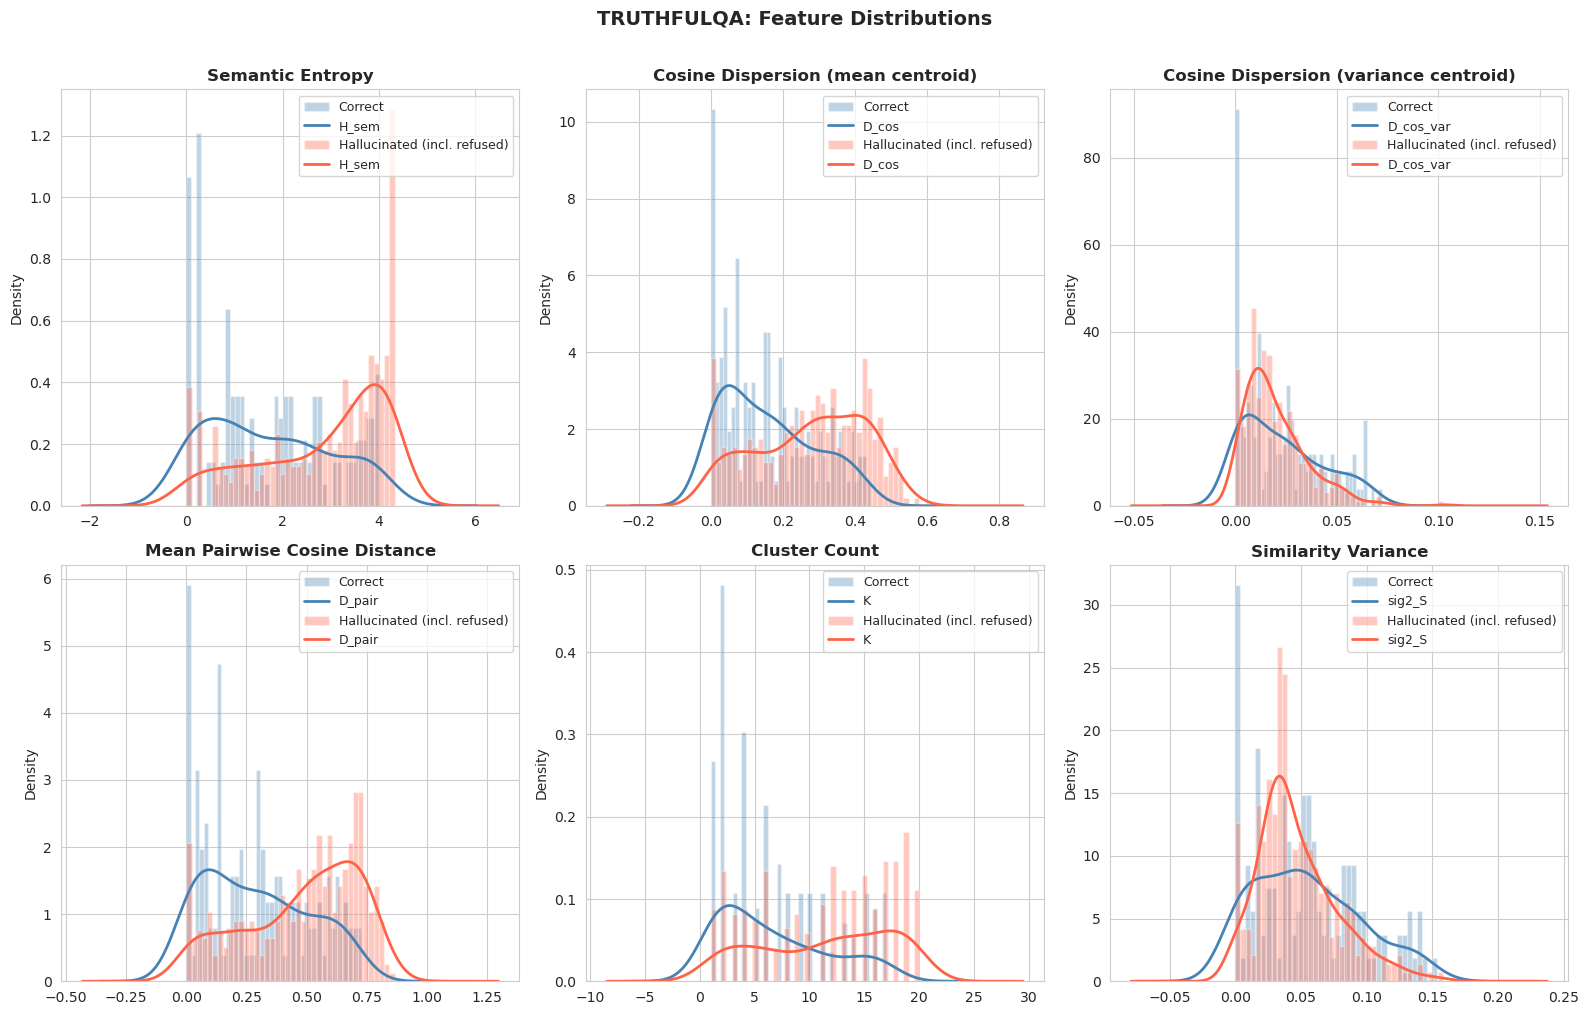

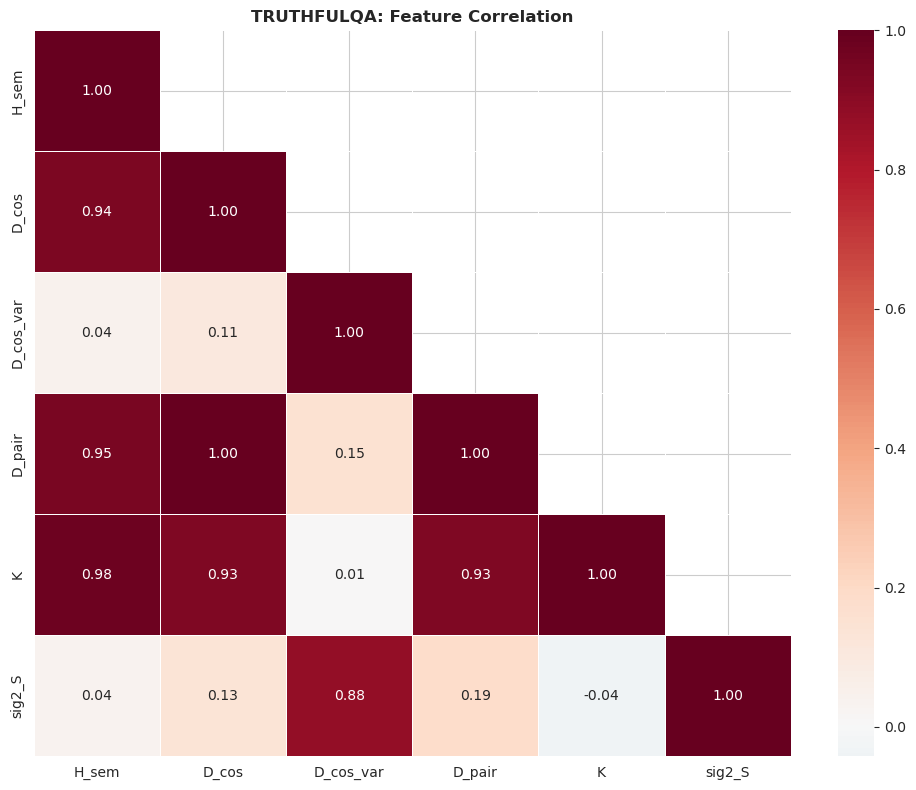

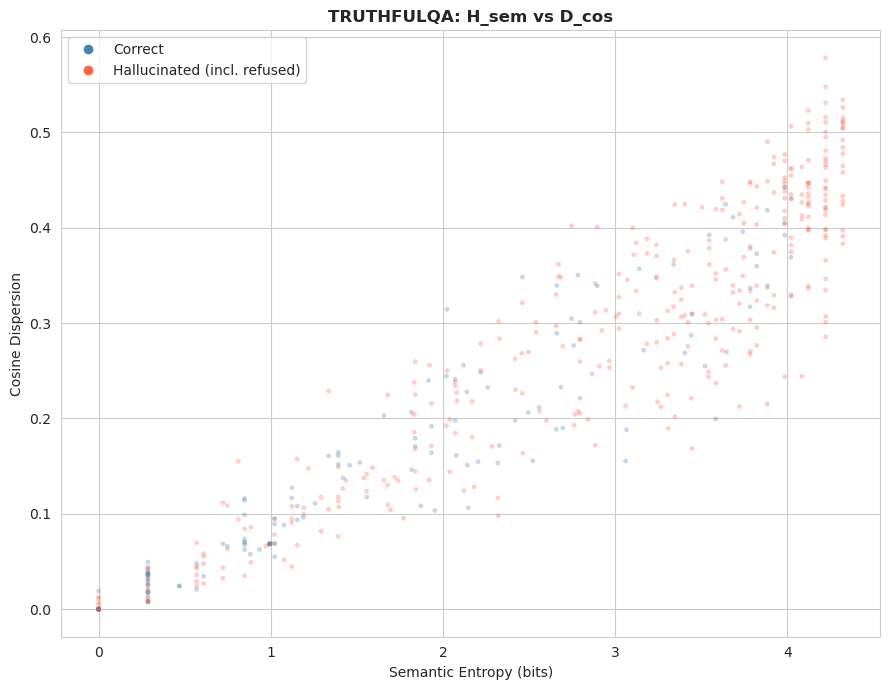

Saved truthfulqa: (500, 28)


In [3]:
feature_dfs = {}

for name, (fname, domain_col) in DATASET_FILES.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()}")
    print(f"{'='*60}")

    # Load
    df = load_dataset(os.path.join(DATA_DIR, fname))
    if domain_col == 'domain_canonical':
        df = add_canonical_domain(df)
    print_loading_summary(df)

    raw_counts = questions_per_domain(df, domain_col=domain_col)

    # Embed
    embs = embed_responses(df, cache_path=os.path.join(NPY_DIR, f'{name}_embeddings.npy'))


    # Extract 7 features per question
    feat_df, n_skipped, skip_details = extract_question_features(
        df, embs,
        sim_threshold=SIM_THRESHOLD, domain_col=domain_col,
    )
    
    display(feat_df[FEATURES + ['label']].describe().round(4))

    # Filtering diagnostic
    analysis_doms, excluded_doms = print_filtering_diagnostic(
        feat_df, raw_counts, n_skipped, MIN_QUESTIONS,
        domain_col=domain_col, skipped_details=skip_details,
    )

    # Hallucination rate by domain (exploratory)
    domain_stats = build_domain_stats(feat_df, domain_col=domain_col)
    fig = plot_hallucination_rate_by_domain(
        feat_df, domain_stats, strict_rate_col='hall_rate_merged', domain_col=domain_col)
    plt.suptitle(f'{name.upper()}: Hallucination Rate by Domain', fontweight='bold', y=1.01)
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_hallu_rate_domain.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Feature distributions
    fig = plot_feature_distributions(feat_df, suptitle=f'{name.upper()}: Feature Distributions')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_feat_distributions.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Correlation matrix
    fig = plot_correlation_matrix(feat_df, title=f'{name.upper()}: Feature Correlation')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_correlation.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Entropy vs dispersion
    fig = plot_entropy_vs_dispersion(feat_df, title=f'{name.upper()}: H_sem vs D_cos')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_entropy_dispersion.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Save
    feat_df.to_csv(os.path.join(CSV_DIR, f'{name}_features.csv'), index=False)
    print(f'Saved {name}: {feat_df.shape}')
    feature_dfs[name] = feat_df

---
## Combined Dataset of 2500 Questions

We concatenate all five feature DataFrames.
The `dataset` column identifies each benchmark for downstream analysis.

Combined: 2,500 questions, hallu rate: 55.8%


,label,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S
dataset,,,,,,,
defan,0.796,2.624,0.250,0.019,0.442,10.176,0.048
halueval,0.072,0.771,0.072,0.012,0.138,3.140,0.031
mmlu,0.784,3.853,0.213,0.018,0.397,16.366,0.033
triviaqa,0.416,1.492,0.156,0.016,0.280,5.784,0.044
truthfulqa,0.720,2.511,0.245,0.021,0.428,10.092,0.049


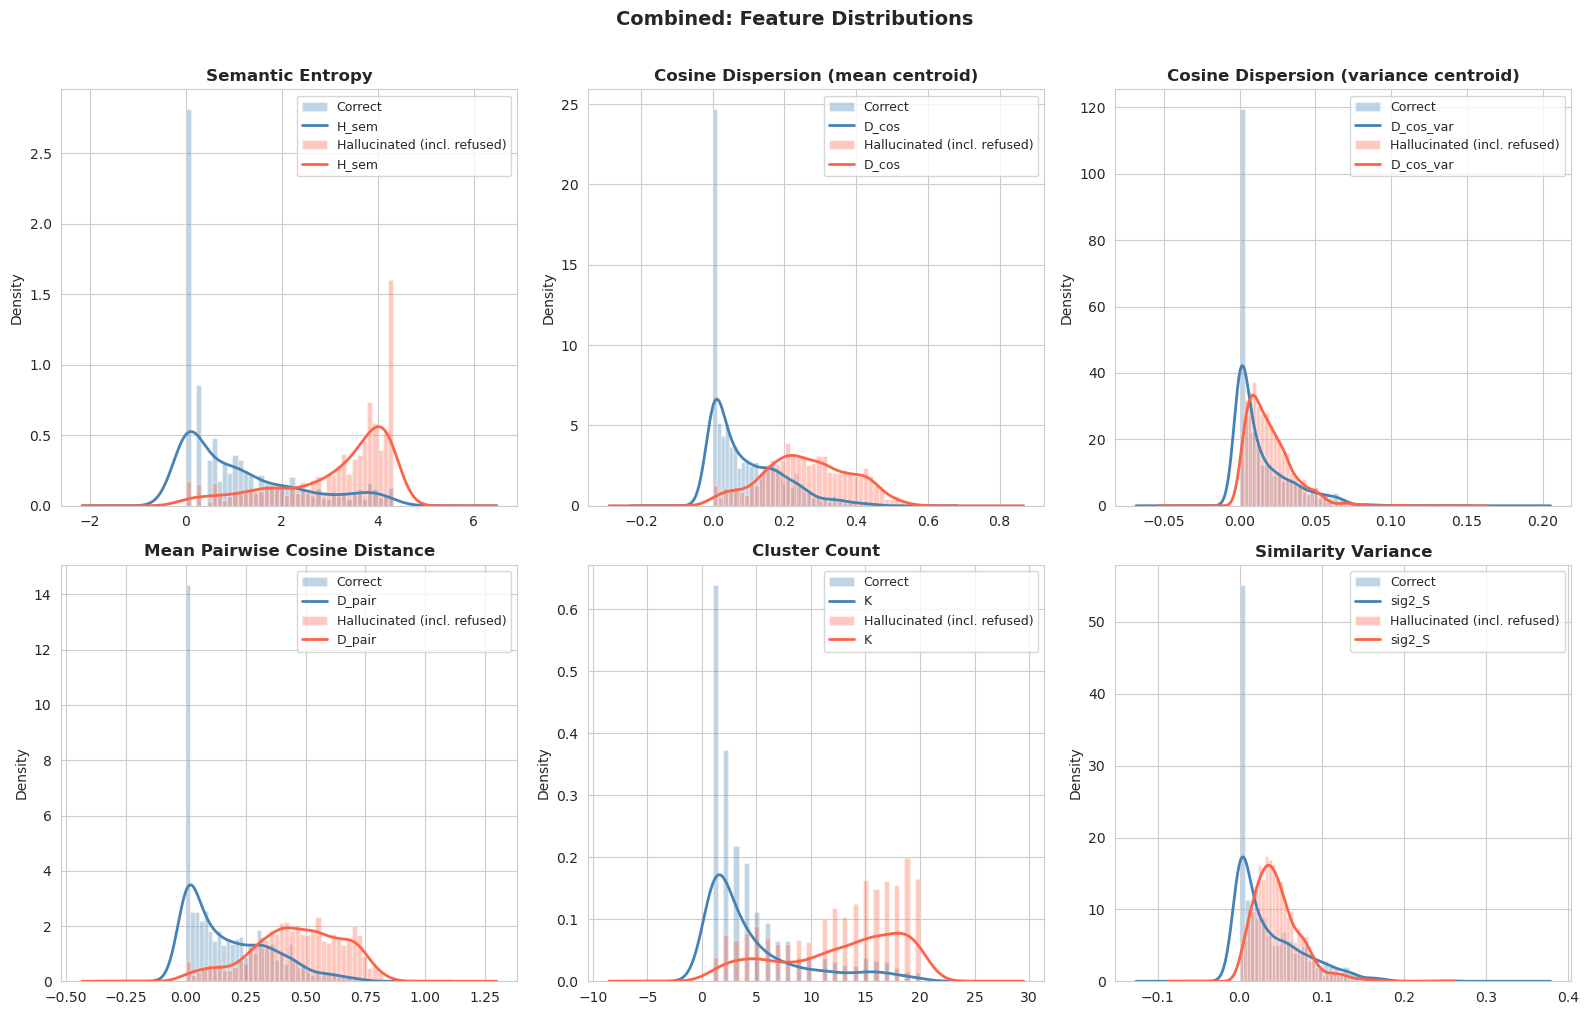

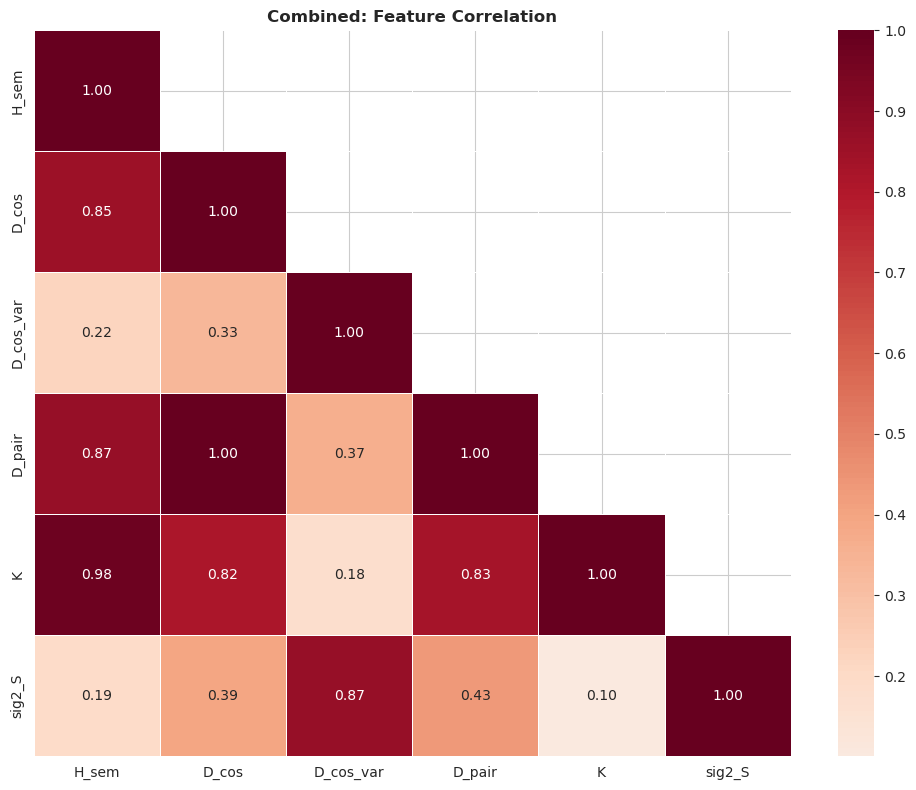

Combined saved: (2500, 30)


In [4]:
feat_all = pd.concat(feature_dfs.values(), ignore_index=True)
print(f'Combined: {len(feat_all):,} questions, hallu rate: {feat_all["label"].mean()*100:.1f}%')
display(feat_all.groupby('dataset')[['label'] + FEATURES].mean().round(3))

fig = plot_feature_distributions(feat_all, suptitle='Combined: Feature Distributions')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_feat_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

fig = plot_correlation_matrix(feat_all, title='Combined: Feature Correlation')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

feat_all.to_csv(os.path.join(CSV_DIR, 'combined_features.csv'), index=False)
print(f'Combined saved: {feat_all.shape}')